# Revision of Simple Linear Regression

- we have one input column and one output column
- <span style="color:cyan">Plot the data to see if there is a linear relationship between the input and output</span>
- If there is a linear relationship, we can fit a line to the data
- The line can be represented by the equation: `y = mx + b`
- m-> weights , b-> bias    
- m and b is found by minimizing the cost function ( total squared error), hence we did using OLS (Ordinary Least Squares) method to derive the formula for m and b

# Multiple Linear Regression

- MLR ka case tb aata hai jb humare paas dataset mei multiple input columns hote hain
- SLR pehle padhaya because, if we can understand thing in lower dimension, then we can easily understand the same thing in higher dimension

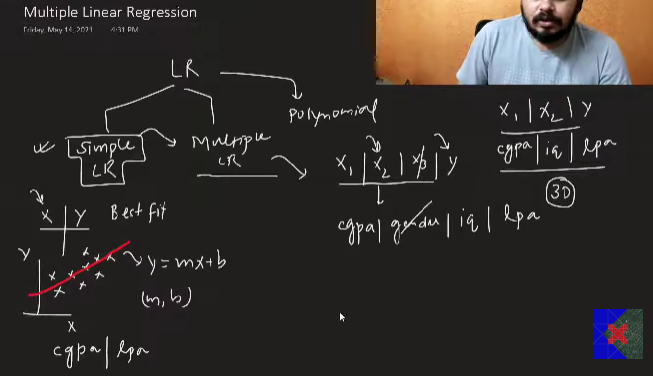

- We took 2 input columns and 1 output column, so we can visualize the data in 3D space (x1:cgpa, x2:iq, y:package)

- **Step 1**: Plot the data in 3D space

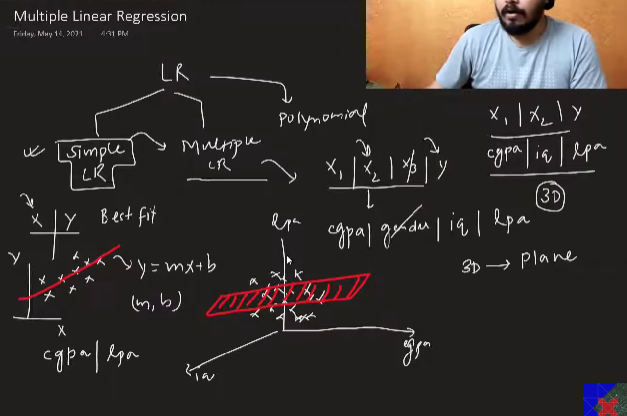

- As in 2D a line can fit the data, in 3D a plane can fit the data, so we can fit a plane to the data

- For 4D or higher dimension, we cannot visualize the data, but we can still fit a **hyperplane** to the data

- The equation of the plane is: `y = m1*x1 + m2*x2 + b` in case of 2 input columns, and in case of n input columns, the equation is: `y = m1*x1 + m2*x2 + ... + mn*xn + b`

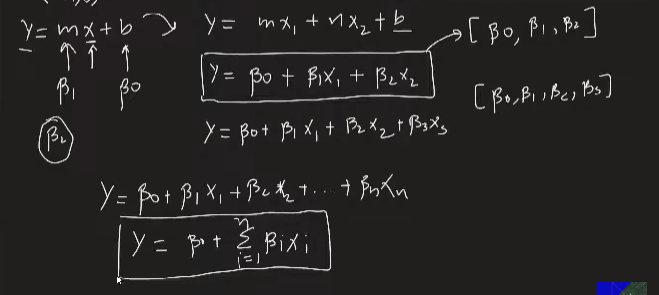

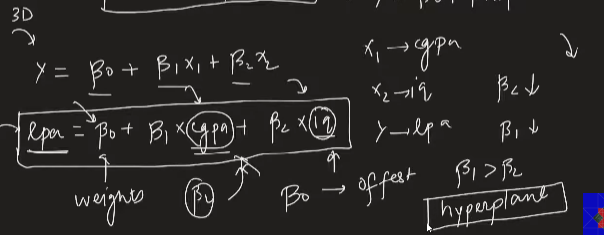

## Hyperplane in n-Dimensions (means n input columns)

### Standard Form

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n
$$

---

### Sigma Notation

$$
y = \beta_0 + \sum_{i=1}^{n} \beta_i x_i
$$

---

### Vector Form

$$
y = \beta_0 + \boldsymbol{\beta}^\top \mathbf{x}
$$

where

$$
\boldsymbol{\beta} =
\begin{bmatrix}
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_n
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
$$

---

### Augmented Vector Form (Including Bias)

$$
y = \boldsymbol{\beta}^\top \mathbf{x}
$$

with

$$
\boldsymbol{\beta} =
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_n
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
1 \\
x_1 \\
\vdots \\
x_n
\end{bmatrix}
$$

- <span style="color:cyan">So, `n` input columns honge to `n+1` coefficients nikalne honge</span>

In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
# generate regression dataset with 2 input features and 1 output feature
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [3]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [4]:
df.shape

(100, 3)

In [5]:
df.head()

,feature1,feature2,target
0,1.597004,0.075250,60.546324
1,0.131729,0.959091,129.342655
2,-1.291845,2.386399,15.768933
3,0.827100,0.118357,24.079550
4,1.220240,-0.029739,102.808894


In [6]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = lr.predict(X_test)

In [12]:
type(y_pred)

numpy.ndarray

In [14]:
y_pred.shape # 1D tensor with 20 values 

(20,)

In [15]:
print(f"MAE: {mean_absolute_error(y_test,y_pred)}")
print(f"MSE: {mean_squared_error(y_test,y_pred)}")
print(f"R2 score: {r2_score(y_test,y_pred)}")

MAE: 55.83700959475666
MSE: 4578.618201728002
R2 score: 0.7927925439197672


- Both the column can explain 79% (R2 score) of the variance in the output column, which is good

In [17]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(x, y)

# Build input points for prediction: shape (100, 2)
final = np.column_stack((xGrid.ravel(), yGrid.ravel()))

# Predict and reshape back to grid
z_final = lr.predict(final).reshape(xGrid.shape)
z = z_final

In [18]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

- So, the plane is the best fit for the data, and it can explain 79% of the variance in the output column, which is good

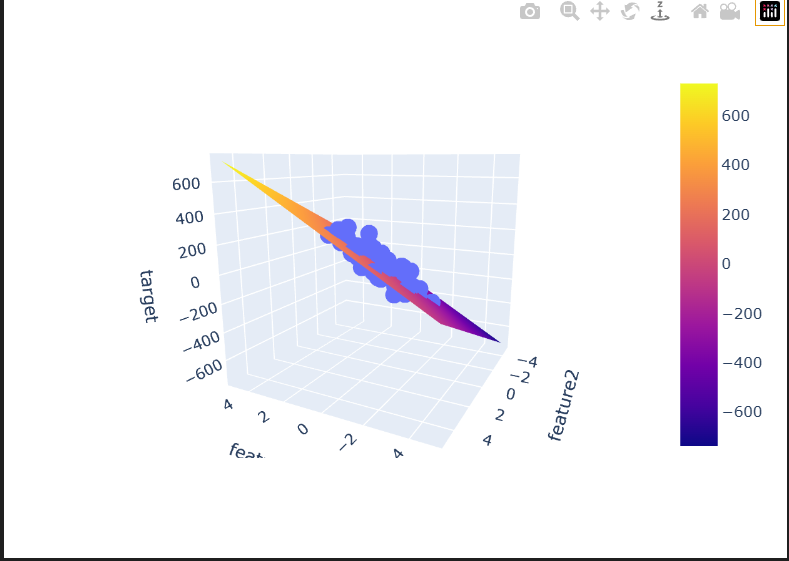

In [ ]:
lr.coef_ 

array([82.52170361, 64.27750618])

-  Above are the values of $\beta_1$ and $\beta_2$

In [ ]:
lr.intercept_ # value of beta_0

np.float64(-3.422738207515799)